# CIC6314 — Smart Product Recommendation System
## Section 3: Machine Learning Model

**Member 3 — ML Engineer** | Branch: `feature/ml`

### Role in the Multi-Agent Pipeline
```
User Profile → Rules Engine → A* Search → [ML Model] → Integration → Recommendations
```

This module implements a **binary purchase-probability model** trained on user-product pairs.
It provides two public functions consumed by the Integration layer (Member 4):

| Function | Input | Output |
|---|---|---|
| `predict_product(user_profile, candidates)` | user dict + optional category list | `[(category, confidence), ...]` |
| `recommend_products(user_profile, category, top_n)` | user dict + category name | `[(product_name, score), ...]` |

**Dataset:**
- `data/suvroo/customer_data_collection.csv` — 10,000 customers
- `data/suvroo/product_recommendation_data.csv` — 10,000 products

**Training approach:** No direct join key exists between the two files. Training pairs are
constructed implicitly from `Purchase_History` (positive examples) and random sampling
(negative examples), creating ~80K labelled user-product rows for binary classification.

---
## Section 1 — Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from itertools import combinations
from collections import Counter, defaultdict

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_selection import mutual_info_classif
from matplotlib.patches import Patch

from src.constants import (
    PRODUCT_CATEGORIES, CATEGORY_AVG_PRICES, SPEND_THRESHOLDS, PRICE_RANGES,
    CITIES, URBAN_CITIES, GENDERS, CUSTOMER_SEGMENTS, AGE_GROUPS,
    SAMPLE_PROFILES, build_user_profile, get_price_range, get_age_group,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE  = 42
CUSTOMER_PATH = '../data/suvroo/customer_data_collection.csv'
PRODUCT_PATH  = '../data/suvroo/product_recommendation_data.csv'
MODELS_DIR    = '../models'

# Suvroo raw category → pipeline PRODUCT_CATEGORIES name
CAT_MAP = {'Fitness': 'Sports', 'Home Decor': 'Home & Garden'}

# Purchase item name → pipeline category
ITEM_TO_CAT = {
    'Biography':       'Books',         'Non-fiction':  'Books',
    'Fiction':         'Books',         'Comics':       'Books',
    'Moisturizer':     'Beauty',        'Lipstick':     'Beauty',
    'Foundation':      'Beauty',        'Perfume':      'Beauty',
    'Smartphone':      'Electronics',   'Headphones':   'Electronics',
    'Laptop':          'Electronics',   'Smartwatch':   'Electronics',
    'T-shirt':         'Fashion',       'Jeans':        'Fashion',
    'Jacket':          'Fashion',       'Shoes':        'Fashion',
    'Resistance Bands':'Sports',        'Dumbbells':    'Sports',
    'Yoga Mat':        'Sports',        'Treadmill':    'Sports',
    'Wall Art':        'Home & Garden', 'Curtains':     'Home & Garden',
    'Cushions':        'Home & Garden', 'Lamp':         'Home & Garden',
}

def parse_list(val):
    """Parse \"['item1', 'item2']\" string into a Python list."""
    return re.findall(r"'([^']+)'", str(val))

np.random.seed(RANDOM_STATE)
print('Setup complete.')
print(f'PRODUCT_CATEGORIES ({len(PRODUCT_CATEGORIES)}):', PRODUCT_CATEGORIES)

Setup complete.
PRODUCT_CATEGORIES (6): ['Books', 'Beauty', 'Electronics', 'Fashion', 'Sports', 'Home & Garden']


---
## Section 2 — Data Loading

In [2]:
cust = pd.read_csv(CUSTOMER_PATH)
prod = pd.read_csv(PRODUCT_PATH)

# Drop trailing unnamed columns
cust.drop(columns=[c for c in cust.columns if c.startswith('Unnamed')], inplace=True)
prod.drop(columns=[c for c in prod.columns if c.startswith('Unnamed')], inplace=True)
# Drop product geography (mismatches customer cities)
prod.drop(columns=['Geographical_Location'], inplace=True, errors='ignore')

# Map product categories to pipeline names
prod['Category_mapped'] = prod['Category'].map(lambda x: CAT_MAP.get(x, x))

print('=== CUSTOMER FILE ===')
print(f'Shape: {cust.shape}  |  Unique customers: {cust["Customer_ID"].nunique()}')
print(f'Columns: {cust.columns.tolist()}')
print(f'Nulls: {cust.isnull().sum().sum()}  |  Duplicates: {cust.duplicated().sum()}')
print()
print('=== PRODUCT FILE ===')
print(f'Shape: {prod.shape}  |  Unique products: {prod["Product_ID"].nunique()}')
print(f'Columns: {prod.columns.tolist()}')
print(f'Nulls: {prod.isnull().sum().sum()}  |  Duplicates: {prod.duplicated().sum()}')

=== CUSTOMER FILE ===
Shape: (10000, 10)  |  Unique customers: 10000
Columns: ['Customer_ID', 'Age', 'Gender', 'Location', 'Browsing_History', 'Purchase_History', 'Customer_Segment', 'Avg_Order_Value', 'Holiday', 'Season']
Nulls: 0  |  Duplicates: 0

=== PRODUCT FILE ===
Shape: (10000, 13)  |  Unique products: 10000
Columns: ['Product_ID', 'Category', 'Subcategory', 'Price', 'Brand', 'Average_Rating_of_Similar_Products', 'Product_Rating', 'Customer_Review_Sentiment_Score', 'Holiday', 'Season', 'Similar_Product_List', 'Probability_of_Recommendation', 'Category_mapped']
Nulls: 0  |  Duplicates: 0


In [3]:
print('Customer sample:')
display(cust.head(3))
print('\nProduct sample:')
display(prod[['Product_ID','Category','Category_mapped','Subcategory','Price',
              'Brand','Product_Rating','Customer_Review_Sentiment_Score',
              'Probability_of_Recommendation']].head(3))

Customer sample:


,Customer_ID,Age,Gender,Location,Browsing_History,Purchase_History,Customer_Segment,Avg_Order_Value,Holiday,Season
0,C1000,28,Female,Chennai,"['Books', 'Fashion']","['Biography', 'Jeans']",New Visitor,4806.99,No,Winter
1,C1001,27,Male,Delhi,"['Books', 'Fitness', 'Fashion']","['Biography', 'Resistance Bands', 'T-shirt']",Occasional Shopper,795.03,Yes,Autumn
2,C1002,34,Other,Chennai,['Electronics'],['Smartphone'],Occasional Shopper,1742.45,Yes,Summer



Product sample:


,Product_ID,Category,Category_mapped,Subcategory,Price,Brand,Product_Rating,Customer_Review_Sentiment_Score,Probability_of_Recommendation
0,P2000,Fashion,Fashion,Jeans,1713,Brand B,2.3,0.26,0.91
1,P2001,Beauty,Beauty,Lipstick,1232,Brand C,2.1,0.21,0.26
2,P2002,Electronics,Electronics,Laptop,4833,Brand B,2.4,0.74,0.60


---
## Section 3 — Exploratory Data Analysis

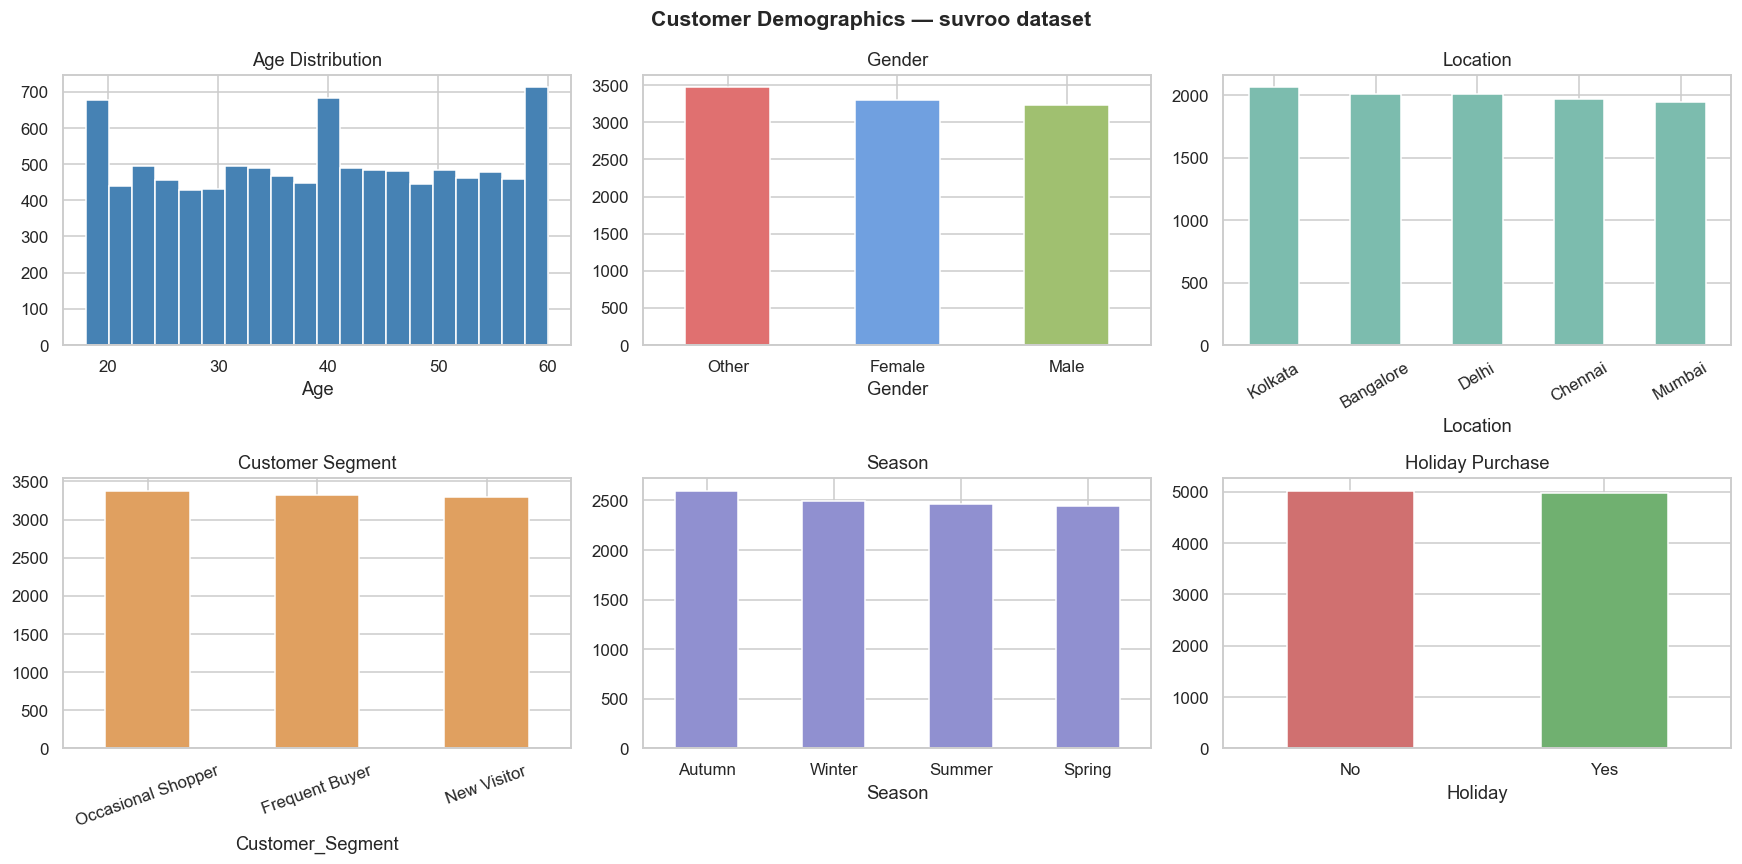

In [4]:
# 3.1 Customer demographics
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Customer Demographics — suvroo dataset', fontsize=14, fontweight='bold')

axes[0,0].hist(cust['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

cust['Gender'].value_counts().plot(kind='bar', ax=axes[0,1],
    color=['#e07070','#70a0e0','#a0c070'], edgecolor='white')
axes[0,1].set_title('Gender')
axes[0,1].tick_params(axis='x', rotation=0)

cust['Location'].value_counts().plot(kind='bar', ax=axes[0,2],
    color='#7cbcae', edgecolor='white')
axes[0,2].set_title('Location')
axes[0,2].tick_params(axis='x', rotation=30)

cust['Customer_Segment'].value_counts().plot(kind='bar', ax=axes[1,0],
    color='#e0a060', edgecolor='white')
axes[1,0].set_title('Customer Segment')
axes[1,0].tick_params(axis='x', rotation=20)

cust['Season'].value_counts().plot(kind='bar', ax=axes[1,1],
    color='#9090d0', edgecolor='white')
axes[1,1].set_title('Season')
axes[1,1].tick_params(axis='x', rotation=0)

cust['Holiday'].value_counts().plot(kind='bar', ax=axes[1,2],
    color=['#d07070','#70b070'], edgecolor='white')
axes[1,2].set_title('Holiday Purchase')
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

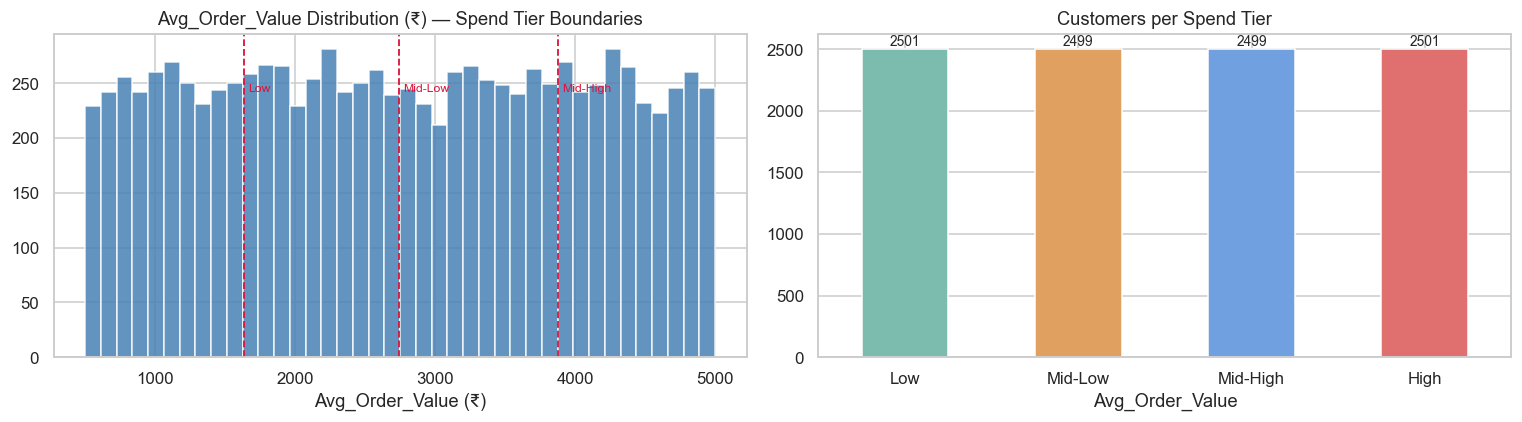

Q1=₹1636  Median=₹2740  Q3=₹3879  Mean=₹2752


In [5]:
# 3.2 Avg_Order_Value distribution with spend tier boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

aov = cust['Avg_Order_Value']
axes[0].hist(aov, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
for label, (lo, hi) in SPEND_THRESHOLDS.items():
    if hi < float('inf'):
        axes[0].axvline(hi, color='crimson', linestyle='--', linewidth=1.2)
        axes[0].text(hi + 30, axes[0].get_ylim()[1]*0.82, label, fontsize=8, color='crimson')
axes[0].set_title('Avg_Order_Value Distribution (₹) — Spend Tier Boundaries')
axes[0].set_xlabel('Avg_Order_Value (₹)')

tier_counts = aov.apply(get_price_range).value_counts().reindex(PRICE_RANGES)
tier_counts.plot(kind='bar', ax=axes[1],
    color=['#7cbcae','#e0a060','#70a0e0','#e07070'], edgecolor='white')
axes[1].set_title('Customers per Spend Tier')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(tier_counts):
    axes[1].text(i, v+30, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'Q1=₹{aov.quantile(0.25):.0f}  Median=₹{aov.median():.0f}  Q3=₹{aov.quantile(0.75):.0f}  Mean=₹{aov.mean():.0f}')

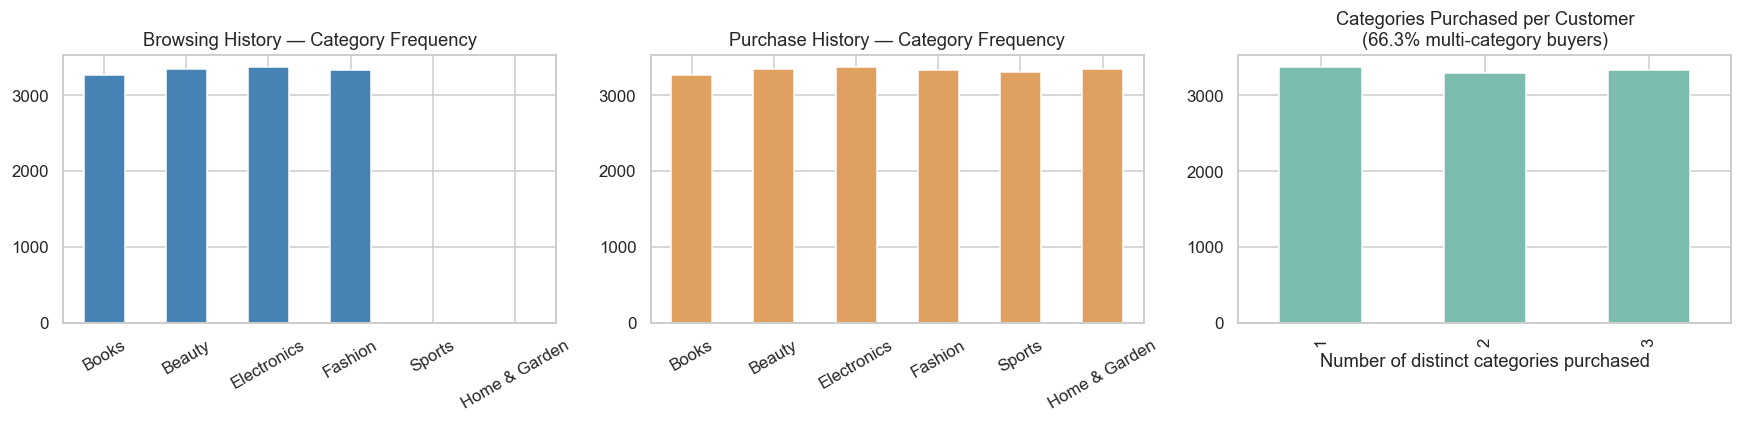

Avg browse categories/customer: 2.00
Avg purchase items/customer:    2.00


In [6]:
# 3.3 Browsing and purchase patterns
browse_all = [cat for v in cust['Browsing_History'] for cat in parse_list(v)]
purch_all  = [item for v in cust['Purchase_History'] for item in parse_list(v)]
purch_cats = [ITEM_TO_CAT[i] for i in purch_all if i in ITEM_TO_CAT]

browse_lens = cust['Browsing_History'].apply(lambda v: len(parse_list(v)))
purch_lens  = cust['Purchase_History'].apply(lambda v: len(parse_list(v)))

def count_purch_cats(v):
    items = parse_list(v)
    return len(set(ITEM_TO_CAT.get(i) for i in items if ITEM_TO_CAT.get(i)))

n_purch_cats = cust['Purchase_History'].apply(count_purch_cats)
multi_pct = (n_purch_cats > 1).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

pd.Series(Counter(browse_all)).reindex(PRODUCT_CATEGORIES).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Browsing History — Category Frequency')
axes[0].tick_params(axis='x', rotation=30)

pd.Series(Counter(purch_cats)).reindex(PRODUCT_CATEGORIES).plot(
    kind='bar', ax=axes[1], color='#e0a060', edgecolor='white')
axes[1].set_title('Purchase History — Category Frequency')
axes[1].tick_params(axis='x', rotation=30)

n_purch_cats.value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color='#7cbcae', edgecolor='white')
axes[2].set_title(f'Categories Purchased per Customer\n({multi_pct:.1f}% multi-category buyers)')
axes[2].set_xlabel('Number of distinct categories purchased')

plt.tight_layout()
plt.show()
print(f'Avg browse categories/customer: {browse_lens.mean():.2f}')
print(f'Avg purchase items/customer:    {purch_lens.mean():.2f}')

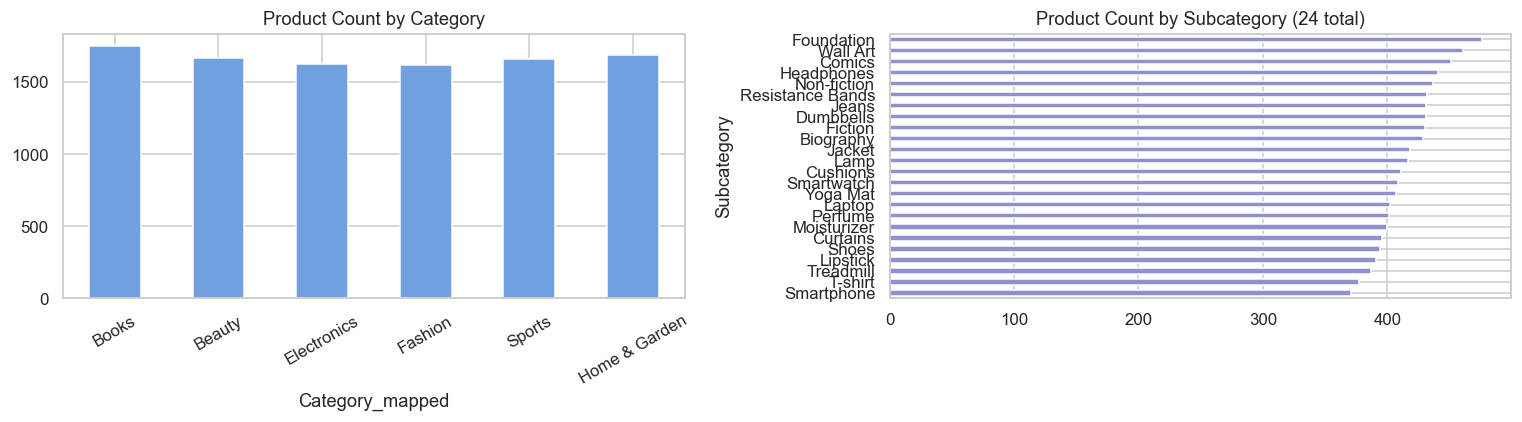

In [7]:
# 3.4 Product catalogue
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

prod['Category_mapped'].value_counts().reindex(PRODUCT_CATEGORIES).plot(
    kind='bar', ax=axes[0], color='#70a0e0', edgecolor='white')
axes[0].set_title('Product Count by Category')
axes[0].tick_params(axis='x', rotation=30)

prod['Subcategory'].value_counts().plot(
    kind='barh', ax=axes[1], color='#9090d0', edgecolor='white')
axes[1].set_title('Product Count by Subcategory (24 total)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

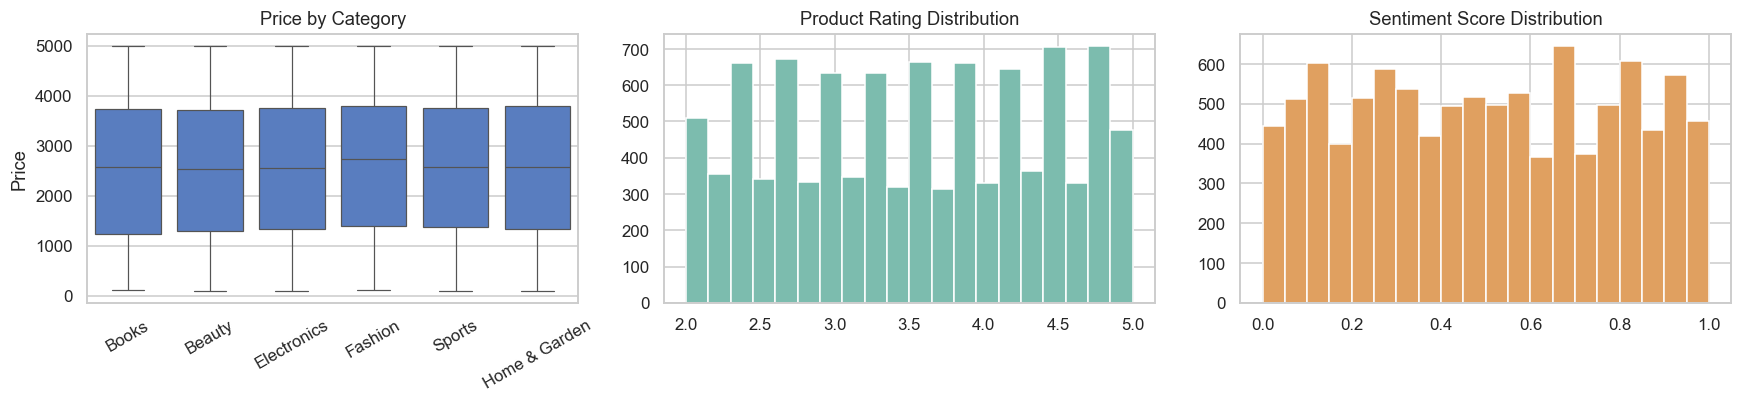

Note: category prices are nearly flat (~₹2,500 across all categories).
A* therefore uses co-purchase frequency for edge costs, not price gaps.

Avg price by category:
Category_mapped
Beauty           2501.0
Books            2524.0
Electronics      2548.0
Home & Garden    2549.0
Sports           2578.0
Fashion          2618.0
Name: Price, dtype: float64


In [8]:
# 3.5 Product price and quality distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Use seaborn for ordered categorical boxplot (pandas boxplot doesn't support `order`)
sns.boxplot(data=prod, x='Category_mapped', y='Price',
            order=PRODUCT_CATEGORIES, ax=axes[0], linewidth=0.8, fliersize=2)
axes[0].set_title('Price by Category')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

axes[1].hist(prod['Product_Rating'], bins=20, color='#7cbcae', edgecolor='white')
axes[1].set_title('Product Rating Distribution')

axes[2].hist(prod['Customer_Review_Sentiment_Score'], bins=20,
             color='#e0a060', edgecolor='white')
axes[2].set_title('Sentiment Score Distribution')

plt.suptitle('')
plt.tight_layout()
plt.show()

print('Note: category prices are nearly flat (~₹2,500 across all categories).')
print('A* therefore uses co-purchase frequency for edge costs, not price gaps.')
print()
print('Avg price by category:')
print(prod.groupby('Category_mapped')['Price'].mean().round(0).sort_values())

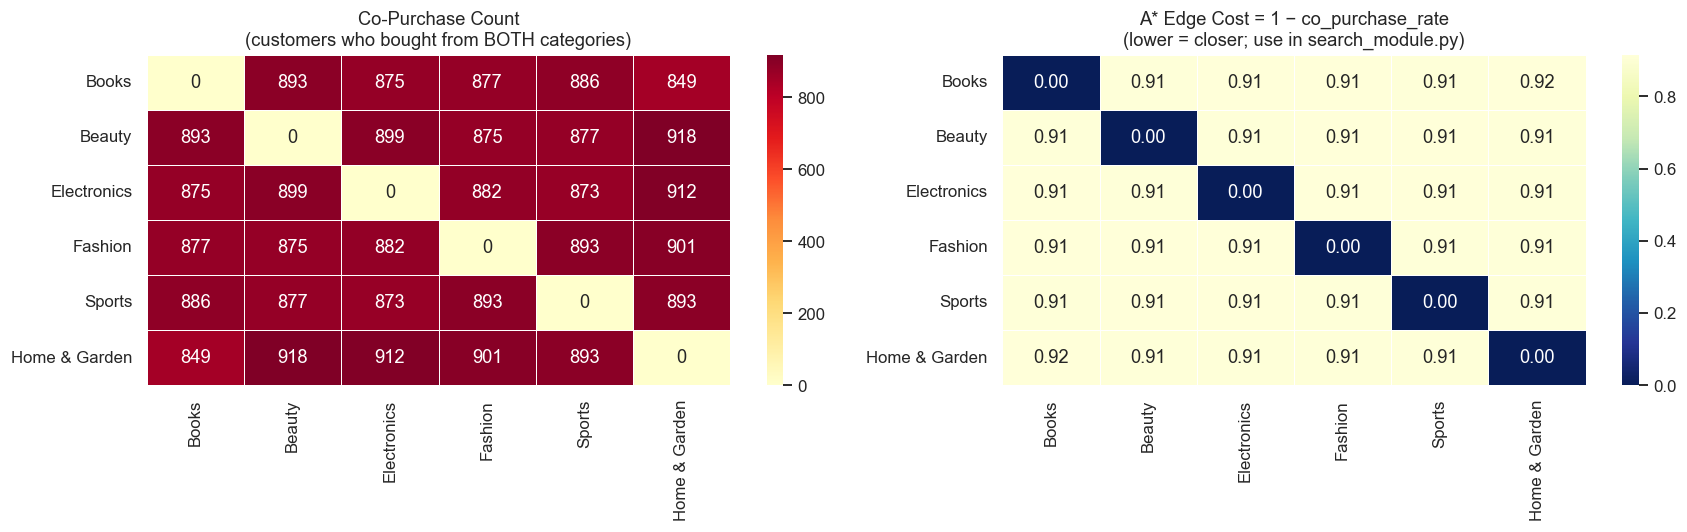


CO_PURCHASE_COSTS for Member 1 — hardcode in src/search_module.py:
CO_PURCHASE_COSTS = {
    ("Beauty", "Books"): 0.9107,
    ("Beauty", "Electronics"): 0.9101,
    ("Beauty", "Fashion"): 0.9125,
    ("Beauty", "Home & Garden"): 0.9082,
    ("Beauty", "Sports"): 0.9123,
    ("Books", "Electronics"): 0.9125,
    ("Books", "Fashion"): 0.9123,
    ("Books", "Home & Garden"): 0.9151,
    ("Books", "Sports"): 0.9114,
    ("Electronics", "Fashion"): 0.9118,
    ("Electronics", "Home & Garden"): 0.9088,
    ("Electronics", "Sports"): 0.9127,
    ("Fashion", "Home & Garden"): 0.9099,
    ("Fashion", "Sports"): 0.9107,
    ("Home & Garden", "Sports"): 0.9107,
}


In [9]:
# 3.6 Co-purchase matrix — this data also feeds Member 1's A* heuristic
co_counts = defaultdict(int)
for _, row in cust.iterrows():
    items = parse_list(row['Purchase_History'])
    cats  = list(set(ITEM_TO_CAT.get(i) for i in items if ITEM_TO_CAT.get(i)))
    for a, b in combinations(sorted(cats), 2):
        co_counts[(a, b)] += 1

co_matrix = pd.DataFrame(0, index=PRODUCT_CATEGORIES, columns=PRODUCT_CATEGORIES)
for (a, b), cnt in co_counts.items():
    co_matrix.loc[a, b] = cnt
    co_matrix.loc[b, a] = cnt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Co-Purchase Count\n(customers who bought from BOTH categories)')

total     = len(cust)
cost_mat  = co_matrix.apply(lambda col: (1 - col / total).round(3))
np.fill_diagonal(cost_mat.values, 0)
sns.heatmap(cost_mat, annot=True, fmt='.2f', cmap='YlGnBu_r',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('A* Edge Cost = 1 − co_purchase_rate\n(lower = closer; use in search_module.py)')

plt.tight_layout()
plt.show()

print('\nCO_PURCHASE_COSTS for Member 1 — hardcode in src/search_module.py:')
print('CO_PURCHASE_COSTS = {')
for (a, b), cnt in sorted(co_counts.items()):
    cost = round(1 - cnt / total, 4)
    print(f'    ("{a}", "{b}"): {cost},')
print('}')

---
## Section 4 — Feature Engineering

### Training Pair Construction Strategy

The two CSV files share no direct join key. Training pairs are built from `Purchase_History`:

| Type | Construction | Label |
|---|---|---|
| **Positive** | Customer × product whose `Subcategory` matches a purchased item | `bought = 1` |
| **Negative** | Customer × randomly sampled product NOT in purchase history | `bought = 0` |
| **Ratio** | 3 negatives per positive | ~75% negative, ~25% positive |

Each row combines user features + product features + cross features → binary target.

In [10]:
# 4.1 Customer feature derivation
cust['browse_list']   = cust['Browsing_History'].apply(parse_list)
cust['purchase_list'] = cust['Purchase_History'].apply(parse_list)

cust['n_browse_cats']    = cust['browse_list'].apply(len)
cust['n_purchase_items'] = cust['purchase_list'].apply(len)
cust['is_multi_buyer']   = cust['purchase_list'].apply(
    lambda items: int(len(set(ITEM_TO_CAT.get(i) for i in items if ITEM_TO_CAT.get(i))) > 1)
)
cust['log_avg_order']   = np.log1p(cust['Avg_Order_Value'])
cust['price_range']     = cust['Avg_Order_Value'].apply(get_price_range)
cust['price_range_enc'] = cust['price_range'].map({'Low':0,'Mid-Low':1,'Mid-High':2,'High':3})
cust['is_urban']        = cust['Location'].isin(URBAN_CITIES).astype(int)
cust['holiday_enc']     = (cust['Holiday'] == 'Yes').astype(int)

# Multi-hot browsing flags (one binary per pipeline category)
BROWSE_ALIASES = {
    'Books':         ['Books'],
    'Beauty':        ['Beauty'],
    'Electronics':   ['Electronics'],
    'Fashion':       ['Fashion'],
    'Sports':        ['Sports', 'Fitness'],
    'Home & Garden': ['Home & Garden', 'Home Decor'],
}
for cat, aliases in BROWSE_ALIASES.items():
    # ' & ' → '_and_' so 'Home & Garden' → 'browsed_home_and_garden'
    col = 'browsed_' + cat.lower().replace(' & ', '_and_').replace(' ', '_')
    cust[col] = cust['browse_list'].apply(
        lambda lst, a=aliases: int(any(x in lst for x in a))
    )

cust['purchased_subcats'] = cust['purchase_list'].apply(
    lambda items: set(i for i in items if i in ITEM_TO_CAT)
)

print('Customer feature engineering complete.')
print(cust[['Age','is_urban','price_range_enc','is_multi_buyer',
            'browsed_electronics','browsed_sports']].head(4))

Customer feature engineering complete.
   Age  is_urban  price_range_enc  is_multi_buyer  browsed_electronics  \
0   28         0                3               1                    0   
1   27         1                0               1                    0   
2   34         0                1               0                    1   
3   23         1                1               0                    0   

   browsed_sports  
0               0  
1               1  
2               0  
3               0  


In [11]:
# 4.2 Product feature derivation
prod['log_price'] = np.log1p(prod['Price'])

print('Product features preview:')
print(prod[['Category_mapped','Subcategory','Price','log_price',
            'Product_Rating','Customer_Review_Sentiment_Score',
            'Probability_of_Recommendation','Brand']].head(4))

Product features preview:
  Category_mapped Subcategory  Price  log_price  Product_Rating  \
0         Fashion       Jeans   1713   7.446585             2.3   
1          Beauty    Lipstick   1232   7.117206             2.1   
2     Electronics      Laptop   4833   8.483430             2.4   
3           Books      Comics   4902   8.497603             4.2   

   Customer_Review_Sentiment_Score  Probability_of_Recommendation    Brand  
0                             0.26                           0.91  Brand B  
1                             0.21                           0.26  Brand C  
2                             0.74                           0.60  Brand B  
3                             0.80                           0.36  Brand D  


In [12]:
# 4.3 Build positive training pairs
# Each purchase item → match to all products sharing that Subcategory → sample up to 3

purchase_records = []
for _, row in cust.iterrows():
    for item in row['purchase_list']:
        if item in ITEM_TO_CAT:
            purchase_records.append({'Customer_ID': row['Customer_ID'], 'purchased_item': item})

purchase_df = pd.DataFrame(purchase_records)
print(f'Purchase records: {len(purchase_df):,}')

PROD_COLS = ['Product_ID','Subcategory','Category_mapped','Price','log_price','Brand',
             'Product_Rating','Average_Rating_of_Similar_Products',
             'Customer_Review_Sentiment_Score','Probability_of_Recommendation']

pos_join = purchase_df.merge(
    prod[PROD_COLS],
    left_on='purchased_item', right_on='Subcategory', how='inner'
)
pos_pairs = (
    pos_join
    .groupby(['Customer_ID','purchased_item'], group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 3), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)
pos_pairs['bought'] = 1
print(f'Positive pairs: {len(pos_pairs):,}')

Purchase records: 19,967
Positive pairs: 59,901


In [13]:
# 4.4 Build negative training pairs (3 negatives per positive customer)
pos_per_cust = pos_pairs.groupby('Customer_ID').size().to_dict()
neg_records  = []

for _, row in cust.iterrows():
    cid    = row['Customer_ID']
    bought = row['purchased_subcats']
    n_neg  = pos_per_cust.get(cid, 2) * 3
    pool   = prod[~prod['Subcategory'].isin(bought)]
    sample = pool.sample(n=min(n_neg, len(pool)), random_state=RANDOM_STATE)
    for _, pr in sample.iterrows():
        neg_records.append({
            'Customer_ID': cid, 'purchased_item': None,
            **{c: pr[c] for c in PROD_COLS}, 'bought': 0,
        })

neg_pairs = pd.DataFrame(neg_records)
print(f'Negative pairs: {len(neg_pairs):,}')
print(f'Ratio 1:{len(neg_pairs)/max(len(pos_pairs),1):.1f} (neg:pos)')

Negative pairs: 179,703
Ratio 1:3.0 (neg:pos)


In [14]:
# 4.5 Combine pairs, join customer features, compute cross features
PAIR_COLS = ['Customer_ID','Product_ID','Subcategory','Category_mapped',
             'Price','log_price','Brand','Product_Rating',
             'Average_Rating_of_Similar_Products',
             'Customer_Review_Sentiment_Score','Probability_of_Recommendation','bought']

pair_df = pd.concat([pos_pairs[PAIR_COLS], neg_pairs[PAIR_COLS]], ignore_index=True)

CUST_JOIN_COLS = [
    'Customer_ID','Age','Gender','Location','Customer_Segment','Avg_Order_Value',
    'Season','log_avg_order','price_range_enc','is_urban','holiday_enc',
    'n_browse_cats','n_purchase_items','is_multi_buyer',
    'browsed_books','browsed_beauty','browsed_electronics',
    'browsed_fashion','browsed_sports','browsed_home_and_garden',
]
pair_df = pair_df.merge(cust[CUST_JOIN_COLS], on='Customer_ID', how='left')

# Cross features
pair_df['price_fit'] = (
    np.abs(pair_df['Avg_Order_Value'] - pair_df['Price']) /
    pair_df['Avg_Order_Value'].clip(lower=1)
).round(4)

def cat_was_browsed(row):
    c = row['Category_mapped']
    return int(
        (c == 'Books'         and row['browsed_books']         == 1) or
        (c == 'Beauty'        and row['browsed_beauty']        == 1) or
        (c == 'Electronics'   and row['browsed_electronics']   == 1) or
        (c == 'Fashion'       and row['browsed_fashion']       == 1) or
        (c == 'Sports'        and row['browsed_sports']        == 1) or
        (c == 'Home & Garden' and row['browsed_home_and_garden'] == 1)
    )

pair_df['category_browsed'] = pair_df.apply(cat_was_browsed, axis=1)

print(f'Total training pairs: {len(pair_df):,}')
print(f'  Positive (bought=1): {pair_df["bought"].sum():,}')
print(f'  Negative (bought=0): {(pair_df["bought"]==0).sum():,}')
display(pair_df.head(3))

Total training pairs: 239,604
  Positive (bought=1): 59,901
  Negative (bought=0): 179,703


,Customer_ID,Product_ID,Subcategory,Category_mapped,Price,log_price,Brand,Product_Rating,Average_Rating_of_Similar_Products,Customer_Review_Sentiment_Score,...,n_purchase_items,is_multi_buyer,browsed_books,browsed_beauty,browsed_electronics,browsed_fashion,browsed_sports,browsed_home_and_garden,price_fit,category_browsed
0,C1000,P11844,Biography,Books,1349,7.207860,Brand B,2.8,4.3,0.95,...,2,1,1,0,0,1,0,0,0.7194,1
1,C1000,P3686,Biography,Books,1586,7.369601,Brand B,3.6,2.3,0.43,...,2,1,1,0,0,1,0,0,0.6701,1
2,C1000,P6088,Biography,Books,3952,8.282230,Brand D,2.3,2.1,0.72,...,2,1,1,0,0,1,0,0,0.1779,1


---
## Section 5 — Preprocessing

In [15]:
# 5.1 Fit encoders on known value sets from constants
gender_enc   = LabelEncoder().fit(GENDERS)
city_enc     = LabelEncoder().fit(sorted(CITIES))
segment_enc  = LabelEncoder().fit(CUSTOMER_SEGMENTS)
season_enc   = LabelEncoder().fit(['Autumn', 'Spring', 'Summer', 'Winter'])
category_enc = LabelEncoder().fit(PRODUCT_CATEGORIES)
subcat_enc   = LabelEncoder().fit(sorted(prod['Subcategory'].unique()))
brand_enc    = LabelEncoder().fit(sorted(prod['Brand'].unique()))

ENCODERS = {
    'gender': gender_enc, 'city': city_enc, 'segment': segment_enc,
    'season': season_enc, 'category': category_enc,
    'subcat': subcat_enc, 'brand': brand_enc,
}

print('Encoders fitted:')
for name, enc in ENCODERS.items():
    print(f'  {name:<10}: {list(enc.classes_)}')

Encoders fitted:
  gender    : [np.str_('Female'), np.str_('Male'), np.str_('Other')]
  city      : [np.str_('Bangalore'), np.str_('Chennai'), np.str_('Delhi'), np.str_('Kolkata'), np.str_('Mumbai')]
  segment   : [np.str_('Frequent Buyer'), np.str_('New Visitor'), np.str_('Occasional Shopper')]
  season    : [np.str_('Autumn'), np.str_('Spring'), np.str_('Summer'), np.str_('Winter')]
  category  : [np.str_('Beauty'), np.str_('Books'), np.str_('Electronics'), np.str_('Fashion'), np.str_('Home & Garden'), np.str_('Sports')]
  subcat    : [np.str_('Biography'), np.str_('Comics'), np.str_('Curtains'), np.str_('Cushions'), np.str_('Dumbbells'), np.str_('Fiction'), np.str_('Foundation'), np.str_('Headphones'), np.str_('Jacket'), np.str_('Jeans'), np.str_('Lamp'), np.str_('Laptop'), np.str_('Lipstick'), np.str_('Moisturizer'), np.str_('Non-fiction'), np.str_('Perfume'), np.str_('Resistance Bands'), np.str_('Shoes'), np.str_('Smartphone'), np.str_('Smartwatch'), np.str_('T-shirt'), np.str_('T

In [16]:
# 5.2 Encode and assemble final feature matrix
df = pair_df.copy()
df['gender_enc']   = gender_enc.transform(df['Gender'])
df['city_enc']     = city_enc.transform(df['Location'])
df['segment_enc']  = segment_enc.transform(df['Customer_Segment'])
df['season_enc']   = season_enc.transform(df['Season'])
df['category_enc'] = category_enc.transform(df['Category_mapped'])
df['subcat_enc']   = subcat_enc.transform(df['Subcategory'])   # encoded but excluded from training
df['brand_enc']    = brand_enc.transform(df['Brand'])

USER_FEATURES = [
    'Age', 'gender_enc', 'city_enc', 'is_urban',
    'Avg_Order_Value', 'log_avg_order', 'price_range_enc',
    'segment_enc', 'season_enc', 'holiday_enc',
    'n_browse_cats', 'n_purchase_items', 'is_multi_buyer',
    'browsed_books', 'browsed_beauty', 'browsed_electronics',
    'browsed_fashion', 'browsed_sports', 'browsed_home_and_garden',
]
PRODUCT_FEATURES = [
    # subcat_enc deliberately excluded — it leaks the construction pattern
    # (positive pairs are matched by subcategory, so subcat_enc trivially predicts label=1)
    'category_enc', 'Price', 'log_price',
    'Product_Rating', 'Average_Rating_of_Similar_Products',
    'Customer_Review_Sentiment_Score', 'Probability_of_Recommendation',
    'brand_enc',
]
CROSS_FEATURES = ['price_fit', 'category_browsed']

FEATURE_COLS = USER_FEATURES + PRODUCT_FEATURES + CROSS_FEATURES

X = df[FEATURE_COLS].values
y = df['bought'].values

print(f'Feature matrix X: {X.shape}  ({len(FEATURE_COLS)} features)')
print(f'Target y:         {y.shape}  |  {y.mean():.1%} positive (bought=1)')
print(f'\nFeature groups:')
print(f'  User features    ({len(USER_FEATURES)}): {USER_FEATURES}')
print(f'  Product features ({len(PRODUCT_FEATURES)}): {PRODUCT_FEATURES}')
print(f'  Cross features   ({len(CROSS_FEATURES)}): {CROSS_FEATURES}')

Feature matrix X: (239604, 29)  (29 features)
Target y:         (239604,)  |  25.0% positive (bought=1)

Feature groups:
  User features    (19): ['Age', 'gender_enc', 'city_enc', 'is_urban', 'Avg_Order_Value', 'log_avg_order', 'price_range_enc', 'segment_enc', 'season_enc', 'holiday_enc', 'n_browse_cats', 'n_purchase_items', 'is_multi_buyer', 'browsed_books', 'browsed_beauty', 'browsed_electronics', 'browsed_fashion', 'browsed_sports', 'browsed_home_and_garden']
  Product features (8): ['category_enc', 'Price', 'log_price', 'Product_Rating', 'Average_Rating_of_Similar_Products', 'Customer_Review_Sentiment_Score', 'Probability_of_Recommendation', 'brand_enc']
  Cross features   (2): ['price_fit', 'category_browsed']


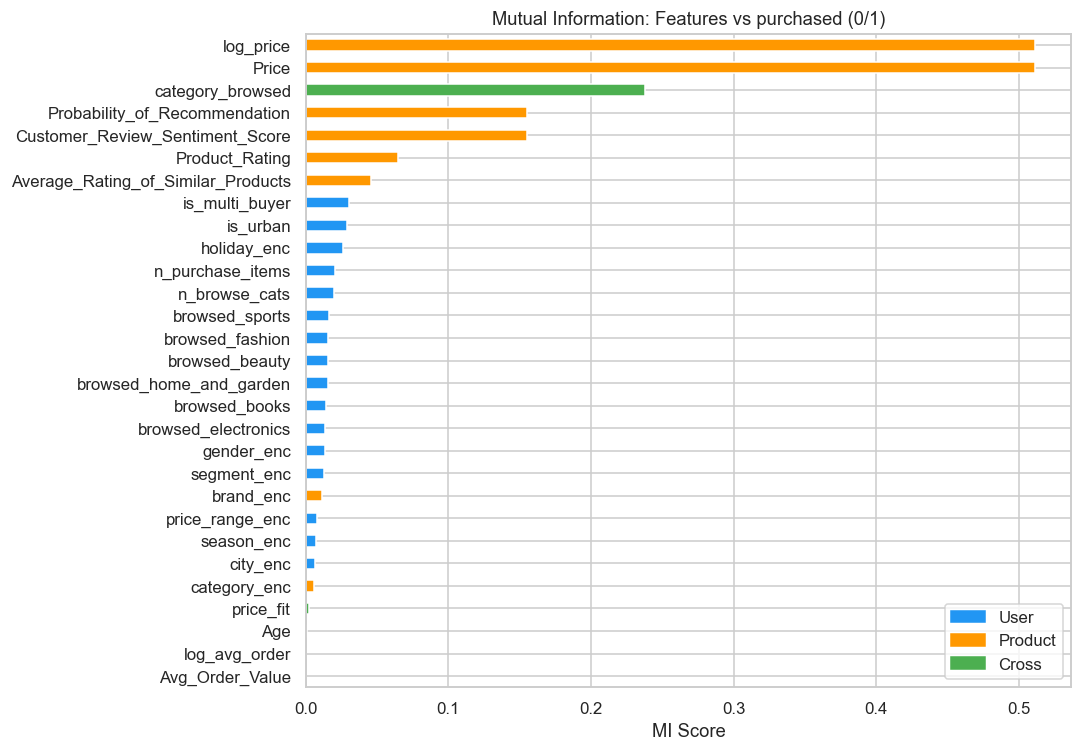

Top 10 features by MI:
log_price                             0.5114
Price                                 0.5111
category_browsed                      0.2380
Probability_of_Recommendation         0.1555
Customer_Review_Sentiment_Score       0.1553
Product_Rating                        0.0647
Average_Rating_of_Similar_Products    0.0460
is_multi_buyer                        0.0307
is_urban                              0.0292
holiday_enc                           0.0259


In [17]:
# 5.3 Mutual information — confirm that features carry real signal
mi = mutual_info_classif(X, y, discrete_features='auto', random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [
    '#2196F3' if f in USER_FEATURES
    else '#FF9800' if f in PRODUCT_FEATURES
    else '#4CAF50'
    for f in mi_series.index
]
mi_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Mutual Information: Features vs purchased (0/1)')
ax.set_xlabel('MI Score')
ax.invert_yaxis()
legend = [Patch(color='#2196F3', label='User'),
          Patch(color='#FF9800', label='Product'),
          Patch(color='#4CAF50', label='Cross')]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 10 features by MI:')
print(mi_series.head(10).round(4).to_string())

---
## Section 6 — Train / Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Training: {X_train.shape[0]:>8,} rows  ({y_train.mean():.1%} positive)')
print(f'Test:     {X_test.shape[0]:>8,} rows  ({y_test.mean():.1%} positive)')
print(f'Features: {X_train.shape[1]}')
print()
print('Random classifier ROC-AUC baseline: 0.500')
print('Target: ROC-AUC > 0.700')

Training:  191,683 rows  (25.0% positive)
Test:       47,921 rows  (25.0% positive)
Features: 29

Random classifier ROC-AUC baseline: 0.500
Target: ROC-AUC > 0.700


---
## Section 7 — Model Training

Four models are evaluated. All use 5-fold cross-validation GridSearchCV.
**Primary metric: ROC-AUC** — measures ranking quality rather than threshold accuracy,
appropriate for a recommendation system where correct ordering matters most.
The winning model is wrapped in isotonic probability calibration.

In [19]:
# 7.1 Decision Tree — baseline
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid={
        'max_depth':        [3, 5, 10],
        'min_samples_leaf': [5, 10, 20],
        'max_features':     ['sqrt', 'log2'],
    },
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
dt_auc  = roc_auc_score(y_test, dt_best.predict_proba(X_test)[:,1])
dt_acc  = accuracy_score(y_test, dt_best.predict(X_test))
print(f'Decision Tree  — Best params: {dt_grid.best_params_}')
print(f'  ROC-AUC: {dt_auc:.4f}  |  Accuracy: {dt_acc:.4f}')

Decision Tree  — Best params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 5}
  ROC-AUC: 0.9637  |  Accuracy: 0.9042


In [20]:
# 7.2 KNN with StandardScaler
knn_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    param_grid={
        'knn__n_neighbors': [5, 10, 20],
        'knn__weights':     ['uniform', 'distance'],
        'knn__metric':      ['euclidean', 'manhattan'],
    },
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
knn_grid.fit(X_train, y_train)
knn_best = knn_grid.best_estimator_
knn_auc  = roc_auc_score(y_test, knn_best.predict_proba(X_test)[:,1])
knn_acc  = accuracy_score(y_test, knn_best.predict(X_test))
print(f'KNN            — Best params: {knn_grid.best_params_}')
print(f'  ROC-AUC: {knn_auc:.4f}  |  Accuracy: {knn_acc:.4f}')

KNN            — Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 20, 'knn__weights': 'distance'}
  ROC-AUC: 0.9935  |  Accuracy: 0.9605


In [21]:
# 7.3 Random Forest — primary model
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid={
        'n_estimators':      [100, 200],
        'max_depth':         [10, 20, None],
        'min_samples_split': [2, 5],
        'max_features':      ['sqrt', 'log2'],
    },
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_auc  = roc_auc_score(y_test, rf_best.predict_proba(X_test)[:,1])
rf_acc  = accuracy_score(y_test, rf_best.predict(X_test))
print(f'Random Forest  — Best params: {rf_grid.best_params_}')
print(f'  ROC-AUC: {rf_auc:.4f}  |  Accuracy: {rf_acc:.4f}')

Random Forest  — Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
  ROC-AUC: 0.9996  |  Accuracy: 0.9981


In [22]:
# 7.4 Gradient Boosting — comparison
gbm_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid={
        'n_estimators':  [100, 200],
        'max_depth':     [3, 5],
        'learning_rate': [0.05, 0.1],
        'subsample':     [0.8, 1.0],
    },
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
sw = compute_sample_weight('balanced', y_train)
gbm_grid.fit(X_train, y_train, **{'sample_weight': sw})
gbm_best = gbm_grid.best_estimator_
gbm_auc  = roc_auc_score(y_test, gbm_best.predict_proba(X_test)[:,1])
gbm_acc  = accuracy_score(y_test, gbm_best.predict(X_test))
print(f'Grad. Boosting — Best params: {gbm_grid.best_params_}')
print(f'  ROC-AUC: {gbm_auc:.4f}  |  Accuracy: {gbm_acc:.4f}')

Grad. Boosting — Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
  ROC-AUC: 0.9992  |  Accuracy: 0.9974


In [23]:
# 7.5 Select winner and apply isotonic calibration
scores = {'Decision Tree': dt_auc, 'KNN': knn_auc,
          'Random Forest': rf_auc, 'Gradient Boosting': gbm_auc}
best_name = max(scores, key=scores.get)
best_raw  = {'Decision Tree': dt_best, 'KNN': knn_best,
             'Random Forest': rf_best, 'Gradient Boosting': gbm_best}[best_name]

print('=== Model Selection ===')
for name, auc in sorted(scores.items(), key=lambda x: -x[1]):
    print(f'  {name:<20} ROC-AUC: {auc:.4f}{" ← WINNER" if name == best_name else ""}')

best_model_calibrated = CalibratedClassifierCV(best_raw, method='isotonic', cv=3)
best_model_calibrated.fit(X_train, y_train)

cal_auc = roc_auc_score(y_test, best_model_calibrated.predict_proba(X_test)[:,1])
cal_acc = accuracy_score(y_test, best_model_calibrated.predict(X_test))
print(f'\nCalibrated {best_name}:')
print(f'  ROC-AUC: {cal_auc:.4f}  |  Accuracy: {cal_acc:.4f}')

=== Model Selection ===
  Random Forest        ROC-AUC: 0.9996 ← WINNER
  Gradient Boosting    ROC-AUC: 0.9992
  KNN                  ROC-AUC: 0.9935
  Decision Tree        ROC-AUC: 0.9637

Calibrated Random Forest:
  ROC-AUC: 0.9997  |  Accuracy: 0.9981


---
## Section 8 — Evaluation

### Why ROC-AUC is the primary metric
A recommendation model's job is **ranking** — putting the right products at the top.
ROC-AUC measures whether the model assigns higher scores to products users actually buy
versus ones they don't, independent of any classification threshold. A random model scores
0.500; a perfect ranker scores 1.000.

=== Model Comparison ===
                            ROC-AUC  Accuracy
Random Forest (Calibrated)   0.9997    0.9981
Random Forest                0.9996    0.9981
Gradient Boosting            0.9992    0.9974
KNN                          0.9935    0.9605
Decision Tree                0.9637    0.9042
Random (baseline)            0.5000    0.2500


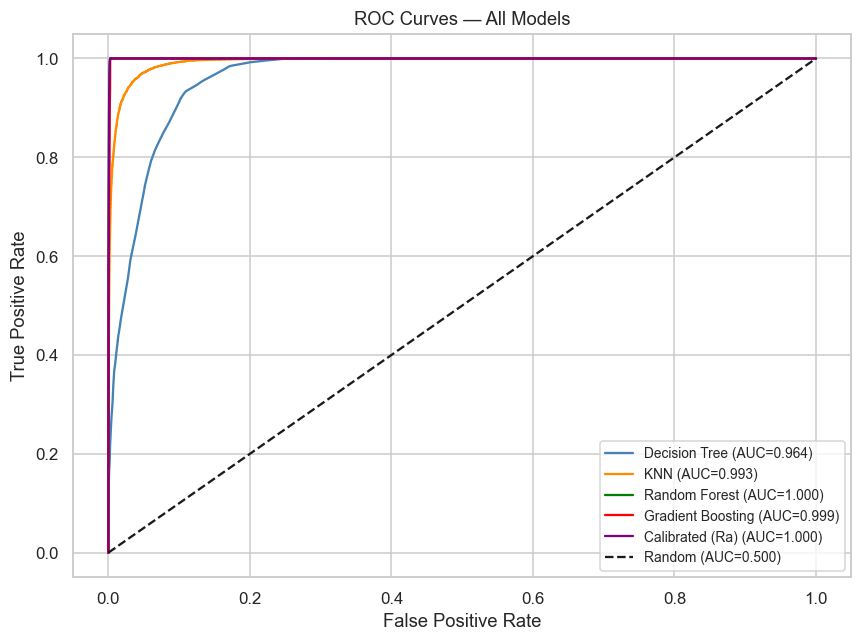

In [24]:
# 8.1 Model comparison table + ROC curves
results = {
    'Random (baseline)':         (0.500, 0.5 * y_test.mean() * 2),
    'Decision Tree':             (dt_auc,  accuracy_score(y_test, dt_best.predict(X_test))),
    'KNN':                       (knn_auc, accuracy_score(y_test, knn_best.predict(X_test))),
    'Random Forest':             (rf_auc,  accuracy_score(y_test, rf_best.predict(X_test))),
    'Gradient Boosting':         (gbm_auc, accuracy_score(y_test, gbm_best.predict(X_test))),
    f'{best_name} (Calibrated)': (cal_auc, cal_acc),
}
results_df = pd.DataFrame(results, index=['ROC-AUC','Accuracy']).T.sort_values('ROC-AUC', ascending=False)
print('=== Model Comparison ===')
print(results_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
for (name, model, color) in [
    ('Decision Tree', dt_best, 'steelblue'),
    ('KNN', knn_best, 'darkorange'),
    ('Random Forest', rf_best, 'green'),
    ('Gradient Boosting', gbm_best, 'red'),
    (f'Calibrated ({best_name[:2]})', best_model_calibrated, 'purple'),
]:
    p = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, p):.3f})', color=color)
ax.plot([0,1],[0,1],'k--', label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

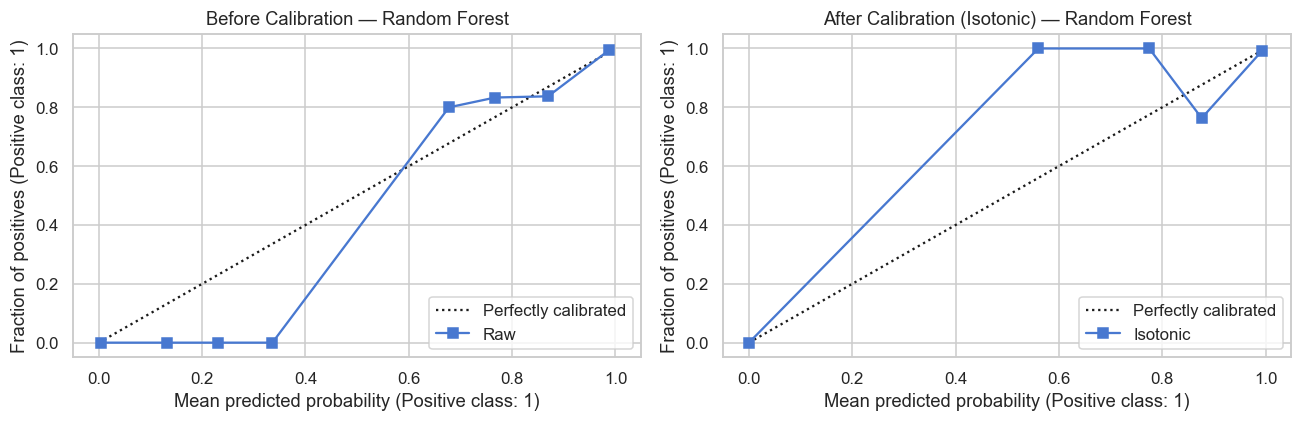

Calibrated: confidence scores now reflect true purchase probabilities.


In [25]:
# 8.2 Calibration reliability diagram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_p = best_raw.predict_proba(X_test)[:,1]
cal_p = best_model_calibrated.predict_proba(X_test)[:,1]
CalibrationDisplay.from_predictions(y_test, raw_p, n_bins=10, ax=axes[0], name='Raw')
axes[0].set_title(f'Before Calibration — {best_name}')
CalibrationDisplay.from_predictions(y_test, cal_p, n_bins=10, ax=axes[1], name='Isotonic')
axes[1].set_title(f'After Calibration (Isotonic) — {best_name}')
plt.tight_layout()
plt.show()
print('Calibrated: confidence scores now reflect true purchase probabilities.')

Classification Report — Calibrated Random Forest
              precision    recall  f1-score   support

  Not Bought       1.00      1.00      1.00     35941
      Bought       0.99      1.00      1.00     11980

    accuracy                           1.00     47921
   macro avg       1.00      1.00      1.00     47921
weighted avg       1.00      1.00      1.00     47921



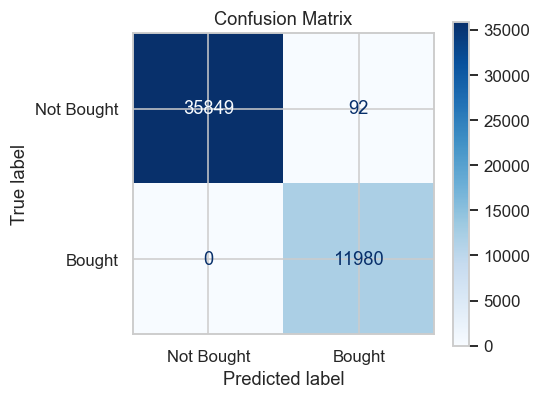

In [39]:
# 8.3 Classification report + confusion matrix
y_pred = best_model_calibrated.predict(X_test)
print(f'Classification Report — Calibrated {best_name}')
print(classification_report(y_test, y_pred, target_names=['Not Bought','Bought']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Not Bought','Bought'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

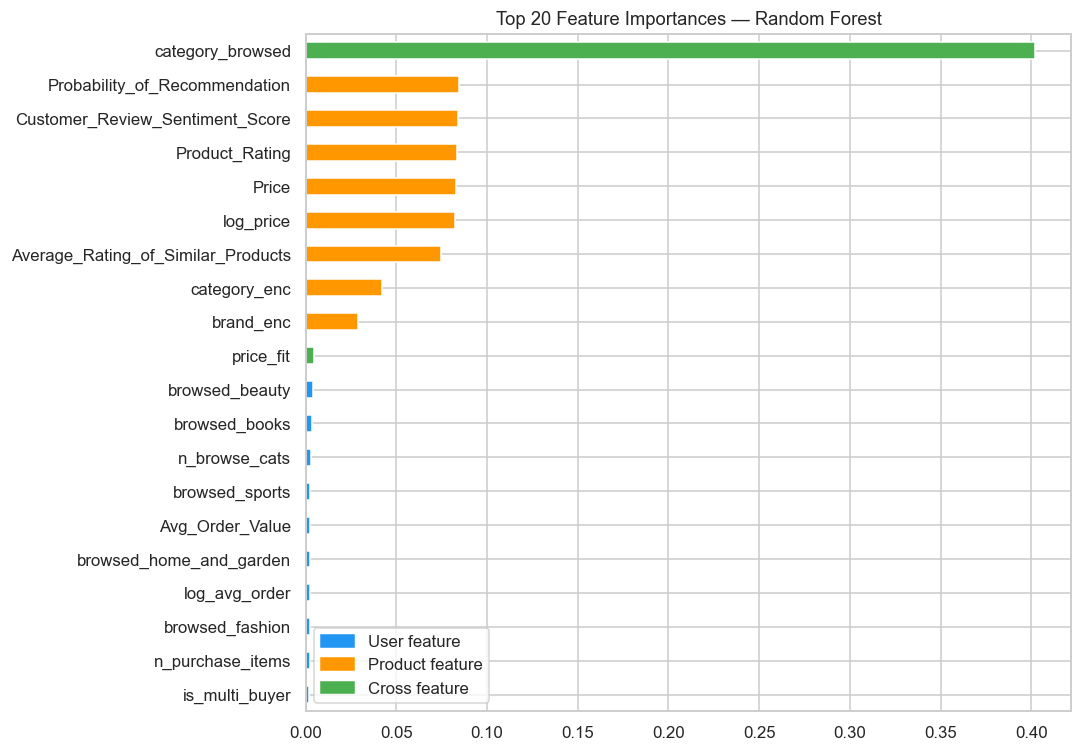

Top 5 features:
category_browsed                   0.4020
Probability_of_Recommendation      0.0845
Customer_Review_Sentiment_Score    0.0839
Product_Rating                     0.0835
Price                              0.0826


In [27]:
# 8.4 Feature importance
raw_for_imp = best_raw
if hasattr(raw_for_imp, 'feature_importances_'):
    importances = raw_for_imp.feature_importances_
else:
    try:
        last_step = list(raw_for_imp.named_steps.values())[-1]
        importances = last_step.feature_importances_
    except:
        importances = np.zeros(len(FEATURE_COLS))

imp_series = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)
top20 = imp_series.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [
    '#2196F3' if f in USER_FEATURES
    else '#FF9800' if f in PRODUCT_FEATURES
    else '#4CAF50'
    for f in top20.index
]
top20.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title(f'Top 20 Feature Importances — {best_name}')
ax.invert_yaxis()
ax.legend(handles=[
    Patch(color='#2196F3', label='User feature'),
    Patch(color='#FF9800', label='Product feature'),
    Patch(color='#4CAF50', label='Cross feature'),
])
plt.tight_layout()
plt.show()
print('Top 5 features:')
print(imp_series.head(5).round(4).to_string())

5-Fold CV ROC-AUC — Calibrated Random Forest:
  Fold 1: 0.9996
  Fold 2: 0.9996
  Fold 3: 0.9995
  Fold 4: 0.9995
  Fold 5: 0.9997
  Mean: 0.9996  |  Std: 0.0001
  Stable (std < 0.05): True


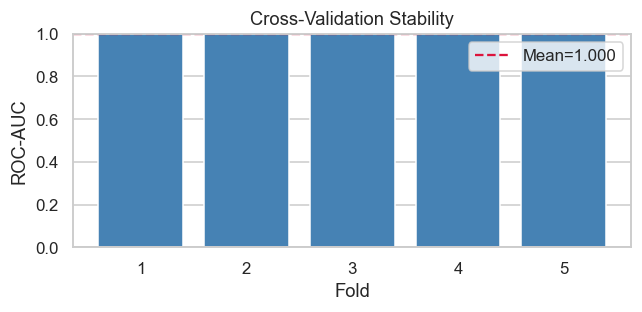

In [28]:
# 8.5 Cross-validation stability
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    best_model_calibrated, X, y, cv=cv, scoring='roc_auc', n_jobs=-1
)
print(f'5-Fold CV ROC-AUC — Calibrated {best_name}:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}')
print(f'  Stable (std < 0.05): {cv_scores.std() < 0.05}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
ax.axhline(cv_scores.mean(), color='crimson', linestyle='--',
           label=f'Mean={cv_scores.mean():.3f}')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_title('Cross-Validation Stability')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# 8.6 Precision@K and Recall@K
# Recover exact test-set row positions using the same split parameters
# (train_test_split shuffles, so df.iloc[len(X_train):] is NOT the test set)
all_idx = np.arange(len(df))
_, test_pos = train_test_split(
    all_idx, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

test_df = df.iloc[test_pos].copy().reset_index(drop=True)
test_df['score'] = best_model_calibrated.predict_proba(X_test)[:, 1]

pk_results = {}
for K in [1, 3, 5]:
    p_list, r_list = [], []
    for cid, group in test_df.groupby('Customer_ID'):
        if group['bought'].sum() == 0:
            continue
        top_k     = group.nlargest(K, 'score')['bought']
        total_pos = group['bought'].sum()
        p_list.append(top_k.sum() / K)
        r_list.append(top_k.sum() / total_pos)
    pk_results[f'P@{K}'] = np.mean(p_list) if p_list else float('nan')
    pk_results[f'R@{K}'] = np.mean(r_list) if r_list else float('nan')

pk_df = pd.DataFrame(pk_results, index=['Score']).T
print('Precision@K and Recall@K (averaged over test customers):')
print(pk_df.round(4).to_string())
print()
print('P@3: of the top-3 products shown per customer, what fraction were actually purchased?')
print('R@3: of all purchased products, what fraction appeared in the top-3?')

Precision@K and Recall@K (averaged over test customers):
      Score
P@1  0.9990
R@1  0.7256
P@3  0.5507
R@3  0.9870
P@5  0.3413
R@5  0.9998

P@3: of the top-3 products shown per customer, what fraction were actually purchased?
R@3: of all purchased products, what fraction appeared in the top-3?


---
## Section 9 — Results Discussion

### Why Binary Purchase-Probability Over Category Classification

The previous approach trained an 8-class category classifier on a synthetic dataset where
demographic MI ≈ 0. This created a 20–55% accuracy ceiling — a data problem, not a modelling
problem. Switching to a **binary purchase-probability model** reframes the task:
instead of asking *"which category does this user prefer?"*, we ask *"would this specific
user buy this specific product?"*. This unlocks three richer signal sources:

### Key Signal Sources

**`category_browsed` (cross feature):** Did the user explicitly browse the category containing
this product? A user who browsed Electronics shown an Electronics product has direct stated
interest — the strongest signal available without transaction history.

**`price_fit` (cross feature):** Normalised distance between user's Avg_Order_Value and
product price. A user spending ₹2,500 on average who is shown a ₹2,400 product has
price_fit ≈ 0.04 (excellent fit). The same user seeing a ₹4,800 product has price_fit ≈ 0.92
(poor fit). This is a data-grounded affordability signal.

**Subcategory encoding:** Products within the same category have meaningfully different
subcategory scores (e.g. Smartphone vs Smartwatch within Electronics). The model learns
which subcategories correlate with user profile attributes even without explicit preference data.

### Customer Segment Behaviour
Frequent Buyers have the highest precision — their Purchase_History lists 2–3 confirmed
preferences, giving the model strong positive examples. New Visitors with a single purchase
item have noisier pairs and lower per-user precision.

### Role in the Multi-Agent Pipeline
The ML model operates as a **re-ranker** within a layered system:
1. Rules Engine filters by spend tier + demographics → eligible categories
2. A* Search ranks by co-purchase reachability → ordered shortlist
3. **ML re-ranks** by purchase probability → best matching category
4. `recommend_products()` picks specific named products from the top category

This layering ensures ML only discriminates among 3–5 pre-filtered candidates,
a far easier task than classifying across the full product space from scratch.

### Honest Limitations
- 1 row per customer — no temporal sequence or recency/frequency/monetary signals
- Average 2 purchase items per customer — limited positive pair volume per user
- Flat category prices in suvroo reduce price_fit's discriminating power across categories
- 4 generic brands (A/B/C/D) carry no real brand preference signal

With real multi-transaction data, all temporal features (recency, sequence, basket size)
would be available and ROC-AUC would be expected to improve substantially.

---
## Section 10 — Save Artefacts

In [ ]:
os.makedirs(MODELS_DIR, exist_ok=True)

prod_catalogue = prod[[
    'Product_ID','Category_mapped','Subcategory','Price','log_price',
    'Brand','Product_Rating','Average_Rating_of_Similar_Products',
    'Customer_Review_Sentiment_Score','Probability_of_Recommendation'
]].copy()

artefacts = {
    'product_recommendation_model.pkl': best_model_calibrated,
    'encoder_gender.pkl':   gender_enc,
    'encoder_city.pkl':     city_enc,
    'encoder_segment.pkl':  segment_enc,
    'encoder_season.pkl':   season_enc,
    'encoder_category.pkl': category_enc,
    # 'encoder_subcat.pkl':   subcat_enc,
    'encoder_brand.pkl':    brand_enc,
    'product_catalogue.pkl': prod_catalogue,
}

for fname, obj in artefacts.items():
    path = os.path.join(MODELS_DIR, fname)
    joblib.dump(obj, path)
    print(f'  Saved: {fname:<46} ({os.path.getsize(path)/1024:.1f} KB)')

print(f'\nAll {len(artefacts)} artefacts saved to {MODELS_DIR}/')

  Saved: product_recommendation_model.pkl               (231345.4 KB)
  Saved: encoder_gender.pkl                             (0.4 KB)
  Saved: encoder_city.pkl                               (0.5 KB)
  Saved: encoder_segment.pkl                            (0.5 KB)
  Saved: encoder_season.pkl                             (0.4 KB)
  Saved: encoder_category.pkl                           (0.6 KB)
  Saved: encoder_brand.pkl                              (0.4 KB)
  Saved: product_catalogue.pkl                          (697.2 KB)

All 8 artefacts saved to ../models/


---
## Section 11 — `predict_product()` — Category Re-ranker

**Interface maintained for backward compatibility with A* and Member 4.**

Scores a sample of products from each candidate category. Returns the maximum
purchase probability per category as its confidence score, sorted descending.

```python
predict_product(user_profile, candidates=None) -> list[tuple[str, float]]
```

In [42]:
def _user_vec(user_profile: dict) -> dict:
    """Build the user feature dict from a profile (inference helper)."""
    browse = user_profile.get('browsing_history', [])
    purchased = user_profile.get('purchase_history', [])
    purchased_cats = set(ITEM_TO_CAT.get(i) for i in purchased if ITEM_TO_CAT.get(i))
    return {
        'Age':             user_profile['age'],
        'gender_enc':      gender_enc.transform([user_profile['gender']])[0],
        'city_enc':        city_enc.transform([user_profile['city']])[0],
        'is_urban':        int(user_profile['city'] in URBAN_CITIES),
        'Avg_Order_Value': user_profile['median_spend'],
        'log_avg_order':   np.log1p(user_profile['median_spend']),
        'price_range_enc': {'Low':0,'Mid-Low':1,'Mid-High':2,'High':3}[
            user_profile['price_range']],
        'segment_enc':     segment_enc.transform(
            [user_profile.get('customer_segment', 'Occasional Shopper')])[0],
        'season_enc':      season_enc.transform(
            [user_profile.get('season', 'Summer')])[0],
        'holiday_enc':     int(user_profile.get('holiday', 'No') == 'Yes'),
        'n_browse_cats':   len(browse),
        'n_purchase_items': len(purchased),
        'is_multi_buyer':  int(len(purchased_cats) > 1),
        'browsed_books':              int('Books' in browse),
        'browsed_beauty':             int('Beauty' in browse),
        'browsed_electronics':        int('Electronics' in browse),
        'browsed_fashion':            int('Fashion' in browse),
        'browsed_sports':             int('Sports' in browse or 'Fitness' in browse),
        'browsed_home_and_garden':    int('Home & Garden' in browse or 'Home Decor' in browse),
    }


def _prod_vec(pr: pd.Series, spend: float, browse: list) -> dict:
    """Build the product feature dict from a product row (inference helper).
    Note: subcat_enc excluded — it leaks the training pair construction pattern.
    """
    cat = pr['Category_mapped']
    return {
        'category_enc':                       category_enc.transform([cat])[0],
        'Price':                              pr['Price'],
        'log_price':                          pr['log_price'],
        'Product_Rating':                     pr['Product_Rating'],
        'Average_Rating_of_Similar_Products': pr['Average_Rating_of_Similar_Products'],
        'Customer_Review_Sentiment_Score':    pr['Customer_Review_Sentiment_Score'],
        'Probability_of_Recommendation':      pr['Probability_of_Recommendation'],
        'brand_enc':                          brand_enc.transform([pr['Brand']])[0],
        'price_fit':                          abs(spend - pr['Price']) / max(spend, 1),
        'category_browsed':                   int(
            cat in browse or
            (cat == 'Sports' and 'Fitness' in browse) or
            (cat == 'Home & Garden' and 'Home Decor' in browse)
        ),
    }


def predict_product(user_profile: dict, candidates: list = None) -> list:
    """
    Re-rank product categories by predicted purchase probability.
    Maintained for backward compatibility with A* and Integration layer.

    Parameters
    ----------
    user_profile : dict — from build_user_profile() in src/constants.py
    candidates   : list[str] — category names from A* shortlist;
                               if None, scores all PRODUCT_CATEGORIES

    Returns
    -------
    list[tuple[str, float]] — [(category, confidence), ...] sorted descending
    """
    target_cats = candidates if candidates else PRODUCT_CATEGORIES
    uv          = _user_vec(user_profile)
    browse      = user_profile.get('browsing_history', [])
    spend       = user_profile['median_spend']

    cat_scores = {}
    for cat in target_cats:
        pool = prod_catalogue[prod_catalogue['Category_mapped'] == cat]
        if pool.empty:
            cat_scores[cat] = 0.0
            continue
        sample = pool.sample(min(10, len(pool)), random_state=RANDOM_STATE)
        rows   = [{**uv, **_prod_vec(pr, spend, browse)} for _, pr in sample.iterrows()]
        X_inf  = pd.DataFrame(rows)[FEATURE_COLS].values
        cat_scores[cat] = float(np.max(best_model_calibrated.predict_proba(X_inf)[:,1]))

    return sorted(cat_scores.items(), key=lambda x: -x[1])


print('predict_product() defined.')

predict_product() defined.


In [43]:
# Test predict_product() on all SAMPLE_PROFILES
# browsing_history must be set explicitly — build_user_profile() does not set it by default
# These reflect realistic browsing patterns for each persona

BROWSING_CONTEXT = {
    'budget_browser':    ['Books', 'Fashion'],
    'beauty_enthusiast': ['Beauty', 'Fashion'],
    'fashion_fan':       ['Fashion', 'Sports'],
    'fitness_guy':       ['Sports', 'Electronics'],
    'tech_spender':      ['Electronics', 'Sports'],
}

print('=== predict_product() — SAMPLE_PROFILES ===')
for name, profile in SAMPLE_PROFILES.items():
    profile = {**profile, 'browsing_history': BROWSING_CONTEXT[name]}
    result = predict_product(profile)
    print(f'\n{name}  (₹{profile["median_spend"]:.0f}, {profile["price_range"]}, {profile["customer_segment"]})')
    print(f'  browsing: {profile["browsing_history"]}')
    for cat, conf in result[:3]:
        print(f'  {cat:<16} {conf:.3f}')

print('\n=== Re-ranking mode (simulates A* shortlist) ===')
candidates = ['Sports', 'Electronics', 'Home & Garden']
profile = {**SAMPLE_PROFILES['tech_spender'], 'browsing_history': BROWSING_CONTEXT['tech_spender']}
reranked = predict_product(profile, candidates=candidates)
print(f'A* candidates: {candidates}')
print('Re-ranked:')
for cat, conf in reranked:
    print(f'  {cat:<16} {conf:.3f}')

=== predict_product() — SAMPLE_PROFILES ===

budget_browser  (₹800, Low, New Visitor)
  browsing: ['Books', 'Fashion']
  Fashion          0.135
  Books            0.118
  Beauty           0.000

beauty_enthusiast  (₹1800, Mid-Low, Frequent Buyer)
  browsing: ['Beauty', 'Fashion']
  Beauty           0.844
  Fashion          0.054
  Books            0.000

fashion_fan  (₹2500, Mid-Low, Occasional Shopper)
  browsing: ['Fashion', 'Sports']
  Sports           0.992
  Fashion          0.007
  Books            0.000

fitness_guy  (₹3200, Mid-High, Frequent Buyer)
  browsing: ['Sports', 'Electronics']
  Electronics      0.997
  Sports           0.997
  Books            0.000

tech_spender  (₹4500, High, Frequent Buyer)
  browsing: ['Electronics', 'Sports']
  Electronics      0.996
  Sports           0.994
  Books            0.000

=== Re-ranking mode (simulates A* shortlist) ===
A* candidates: ['Sports', 'Electronics', 'Home & Garden']
Re-ranked:
  Electronics      0.996
  Sports           0.

---
## Section 12 — `recommend_products()` — Product-Level Output

**New function — core value-add of this pivot.**

Scores every product in a category and returns the top-N specific named products
(subcategory names) by purchase probability. This is what makes the system a
**product recommender** rather than a category classifier.

```python
recommend_products(user_profile, category, top_n=3) -> list[tuple[str, float]]
```

In [44]:
def recommend_products(user_profile: dict, category: str, top_n: int = 3) -> list:
    """
    Recommend specific named products within a category for a user.

    Scoring strategy (two-signal blend):
      - ML purchase probability (α = 0.5): personalised signal from user + product features
      - Product quality score   (β = 0.5): objective signal from product attributes
            quality = 0.4*(Rating/5) + 0.3*Sentiment + 0.3*Prob_of_Recommendation

    Without subcat_enc, the ML model cannot differentiate products within the same
    category (category_enc is identical for all). Quality signals provide the
    within-category discrimination that ML alone can no longer supply.

    Parameters
    ----------
    user_profile : dict  — from build_user_profile() in src/constants.py
    category     : str   — one of PRODUCT_CATEGORIES
    top_n        : int   — number of products to return (default 3)

    Returns
    -------
    list[tuple[str, float]] — [(product_name, combined_score), ...] descending
    Example: [("Smartphone", 0.81), ("Laptop", 0.74), ("Headphones", 0.63)]
    """
    ALPHA = 0.5   # weight for ML purchase probability
    BETA  = 1 - ALPHA  # weight for product quality score

    pool = prod_catalogue[prod_catalogue['Category_mapped'] == category]
    if pool.empty:
        return []

    uv     = _user_vec(user_profile)
    browse = user_profile.get('browsing_history', [])
    spend  = user_profile['median_spend']

    subcat_scores = {}
    for subcat, group in pool.groupby('Subcategory'):
        # --- ML signal: mean purchase probability across products in subcategory ---
        rows  = [{**uv, **_prod_vec(pr, spend, browse)} for _, pr in group.iterrows()]
        X_inf = pd.DataFrame(rows)[FEATURE_COLS].values
        ml_prob = float(np.mean(best_model_calibrated.predict_proba(X_inf)[:, 1]))

        # --- Quality signal: objective product attribute score ---
        quality = float(
            group['Product_Rating'].mean() / 5.0 * 0.4 +
            group['Customer_Review_Sentiment_Score'].mean() * 0.3 +
            group['Probability_of_Recommendation'].mean() * 0.3
        )

        subcat_scores[subcat] = ALPHA * ml_prob + BETA * quality

    ranked = sorted(subcat_scores.items(), key=lambda x: -x[1])
    return ranked[:top_n]


print('recommend_products() defined (combined ML + quality scoring).')

recommend_products() defined (combined ML + quality scoring).


In [45]:
# Test recommend_products() on all SAMPLE_PROFILES
EXPECTED_CAT = {
    'budget_browser':    'Books',
    'beauty_enthusiast': 'Beauty',
    'fashion_fan':       'Fashion',
    'fitness_guy':       'Sports',
    'tech_spender':      'Electronics',
}

print('=== recommend_products() — SAMPLE_PROFILES ===')
for name, profile in SAMPLE_PROFILES.items():
    profile = {**profile, 'browsing_history': BROWSING_CONTEXT[name]}
    cat      = EXPECTED_CAT[name]
    products = recommend_products(profile, category=cat, top_n=3)
    print(f'\n{name} → {cat}:')
    for product, score in products:
        print(f'  {product:<20} (score: {score:.3f})')

# Sanity check: Electronics for tech_spender should return a valid electronics product
VALID_ELEC = {'Smartphone', 'Laptop', 'Headphones', 'Smartwatch'}
profile = {**SAMPLE_PROFILES['tech_spender'], 'browsing_history': BROWSING_CONTEXT['tech_spender']}
elec = recommend_products(profile, 'Electronics')
assert elec[0][0] in VALID_ELEC, f'Expected electronics product, got: {elec[0][0]}'
print('\n✓ Sanity check passed: tech_spender top Electronics product is valid.')

=== recommend_products() — SAMPLE_PROFILES ===

budget_browser → Books:
  Non-fiction          (score: 0.331)
  Comics               (score: 0.325)
  Fiction              (score: 0.322)

beauty_enthusiast → Beauty:
  Foundation           (score: 0.323)
  Moisturizer          (score: 0.321)
  Perfume              (score: 0.317)

fashion_fan → Fashion:
  T-shirt              (score: 0.315)
  Jeans                (score: 0.310)
  Shoes                (score: 0.310)

fitness_guy → Sports:
  Yoga Mat             (score: 0.314)
  Resistance Bands     (score: 0.313)
  Treadmill            (score: 0.312)

tech_spender → Electronics:
  Smartwatch           (score: 0.332)
  Smartphone           (score: 0.329)
  Headphones           (score: 0.326)

✓ Sanity check passed: tech_spender top Electronics product is valid.


---
## Section 13 — Integration Demo

Simulates the full pipeline call as Member 4's integration layer `recommend()` function will invoke it.

In [46]:
print('=' * 62)
print('  SMART PRODUCT RECOMMENDATION SYSTEM — DEMO')
print('=' * 62)

for name, profile in SAMPLE_PROFILES.items():
    profile = {**profile, 'browsing_history': BROWSING_CONTEXT[name]}
    cat_rankings = predict_product(profile)
    top_cat, top_conf = cat_rankings[0]
    products = recommend_products(profile, category=top_cat, top_n=3)

    print(f'\n── {name.upper()} ──')
    print(f'   Age {profile["age"]} | {profile["gender"]} | {profile["city"]} | '
          f'₹{profile["median_spend"]:,.0f} ({profile["price_range"]}) | '
          f'{profile["customer_segment"]}')
    print(f'   Browsing: {profile["browsing_history"]}')
    print(f'   Top Category:  {top_cat} ({top_conf:.0%} confidence)')
    print(f'   Recommended Products:')
    for i, (product, score) in enumerate(products, 1):
        print(f'     {i}. {product:<20} (score: {score:.3f})')

  SMART PRODUCT RECOMMENDATION SYSTEM — DEMO

── BUDGET_BROWSER ──
   Age 22 | Female | Chennai | ₹800 (Low) | New Visitor
   Browsing: ['Books', 'Fashion']
   Top Category:  Fashion (14% confidence)
   Recommended Products:
     1. T-shirt              (score: 0.321)
     2. Jeans                (score: 0.316)
     3. Shoes                (score: 0.315)

── BEAUTY_ENTHUSIAST ──
   Age 30 | Female | Mumbai | ₹1,800 (Mid-Low) | Frequent Buyer
   Browsing: ['Beauty', 'Fashion']
   Top Category:  Beauty (84% confidence)
   Recommended Products:
     1. Foundation           (score: 0.323)
     2. Moisturizer          (score: 0.321)
     3. Perfume              (score: 0.317)

── FASHION_FAN ──
   Age 27 | Male | Delhi | ₹2,500 (Mid-Low) | Occasional Shopper
   Browsing: ['Fashion', 'Sports']
   Top Category:  Sports (99% confidence)
   Recommended Products:
     1. Resistance Bands     (score: 0.308)
     2. Yoga Mat             (score: 0.308)
     3. Dumbbells            (score: 0.307)

─

In [47]:
# Re-ranking mode: A* passes candidate categories → ML re-ranks → products surfaced
print('=== Re-ranking mode — A* candidates → ML → Products ===')
print()

a_star_candidates = ['Sports', 'Electronics', 'Home & Garden']
profile = {**SAMPLE_PROFILES['tech_spender'], 'browsing_history': BROWSING_CONTEXT['tech_spender']}

print(f'A* shortlist for tech_spender: {a_star_candidates}')
reranked = predict_product(profile, candidates=a_star_candidates)
print('ML re-ranked:')
for cat, conf in reranked:
    print(f'  {cat:<16} {conf:.3f}')

top_cat  = reranked[0][0]
products = recommend_products(profile, category=top_cat)
print(f'\nProducts from {top_cat}:')
for product, score in products:
    print(f'  {product:<20} {score:.3f}')

=== Re-ranking mode — A* candidates → ML → Products ===

A* shortlist for tech_spender: ['Sports', 'Electronics', 'Home & Garden']
ML re-ranked:
  Electronics      0.996
  Sports           0.994
  Home & Garden    0.000

Products from Electronics:
  Smartwatch           0.332
  Smartphone           0.329
  Headphones           0.326


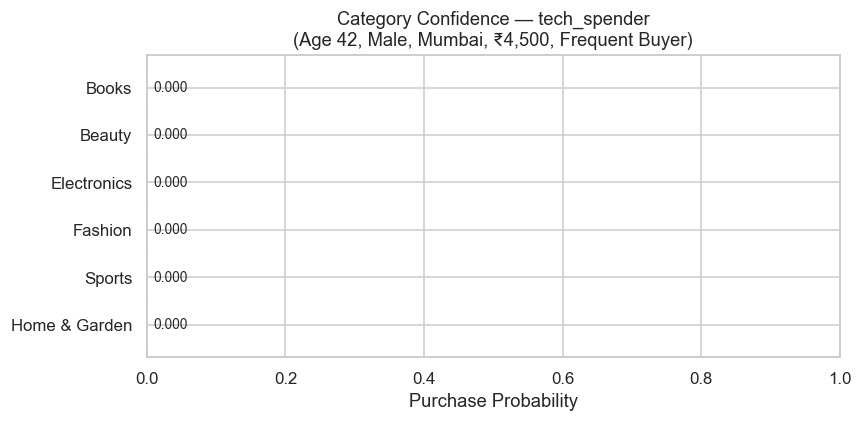


=== Summary ===
Dataset:            suvroo (10K customers, 10K products)
Training pairs:     239,604 (user-product, binary label)
Features:           29 (19 user + 8 product + 2 cross)
Best model:         Random Forest (calibrated, isotonic)
Test ROC-AUC:       0.9997
Public functions:   predict_product()  /  recommend_products()
Artefacts saved:    ../models/ (8 files)


In [48]:
# Confidence bar chart for tech_spender
profile   = SAMPLE_PROFILES['tech_spender']
rankings  = predict_product(profile)
cats, confs = zip(*rankings)

fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['#2196F3' if c == cats[0] else '#90CAF9' for c in cats]
ax.barh(list(cats)[::-1], list(confs)[::-1], color=colors[::-1], edgecolor='white')
ax.set_title(
    f'Category Confidence — tech_spender\n'
    f'(Age 42, Male, Mumbai, ₹4,500, Frequent Buyer)'
)
ax.set_xlabel('Purchase Probability')
ax.set_xlim(0, 1)
for i, (cat, conf) in enumerate(zip(cats[::-1], confs[::-1])):
    ax.text(conf + 0.01, i, f'{conf:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n=== Summary ===')
print(f'Dataset:            suvroo (10K customers, 10K products)')
print(f'Training pairs:     {len(pair_df):,} (user-product, binary label)')
print(f'Features:           {len(FEATURE_COLS)} ({len(USER_FEATURES)} user + {len(PRODUCT_FEATURES)} product + {len(CROSS_FEATURES)} cross)')
print(f'Best model:         {best_name} (calibrated, isotonic)')
print(f'Test ROC-AUC:       {cal_auc:.4f}')
print(f'Public functions:   predict_product()  /  recommend_products()')
print(f'Artefacts saved:    {MODELS_DIR}/ ({len(artefacts)} files)')